In [7]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

dataset_path = '/kaggle/input/datasets/dhoogla/csecicids2018'
files = sorted([f for f in os.listdir(dataset_path) if f.endswith('.parquet')])

print("Available files:")
for f in files:
    size_mb = os.path.getsize(os.path.join(dataset_path, f)) / 1e6
    print(f"  {f:70s} {size_mb:.1f} MB")

Available files:
  Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet             83.5 MB
  Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet      76.4 MB
  DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet             89.5 MB
  DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet           33.4 MB
  DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet             98.6 MB
  DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet               58.0 MB
  Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet          51.0 MB
  Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet           29.3 MB
  Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet             104.0 MB
  Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet               101.4 MB


In [9]:
df_raw = pd.read_parquet(os.path.join(dataset_path, files[0]))
df_raw.columns = df_raw.columns.str.strip()

print(f"Shape: {df_raw.shape}")
print(f"\nAll columns ({len(df_raw.columns)}):")
for col in df_raw.columns:
    sample = df_raw[col].dropna().iloc[0] if df_raw[col].notna().any() else 'N/A'
    print(f"  '{col}' → dtype={df_raw[col].dtype}, sample={sample}")

Shape: (771587, 78)

All columns (78):
  'Protocol' → dtype=int8, sample=6
  'Flow Duration' → dtype=int32, sample=141385
  'Total Fwd Packets' → dtype=int32, sample=9
  'Total Backward Packets' → dtype=int32, sample=7
  'Fwd Packets Length Total' → dtype=int32, sample=553
  'Bwd Packets Length Total' → dtype=float32, sample=3773.0
  'Fwd Packet Length Max' → dtype=int16, sample=202
  'Fwd Packet Length Min' → dtype=int16, sample=0
  'Fwd Packet Length Mean' → dtype=float32, sample=61.44444274902344
  'Fwd Packet Length Std' → dtype=float32, sample=87.53443908691406
  'Bwd Packet Length Max' → dtype=int16, sample=1460
  'Bwd Packet Length Min' → dtype=int16, sample=0
  'Bwd Packet Length Mean' → dtype=float32, sample=539.0
  'Bwd Packet Length Std' → dtype=float32, sample=655.4329223632812
  'Flow Bytes/s' → dtype=float64, sample=30597.30523
  'Flow Packets/s' → dtype=float64, sample=113.1661775
  'Flow IAT Mean' → dtype=float32, sample=9425.6669921875
  'Flow IAT Std' → dtype=float32,

In [18]:
COLUMN_MAP = {
    # Exact column name from parquet    → standardized name
    'Total Fwd Packets'                 : 'fwd_pkts',        # n_fwd_pkts
    'Total Backward Packets'            : 'bwd_pkts',        # n_bwd_pkts
    'Flow Duration'                     : 'flow_duration',   # sum_flx_dur
    'Fwd Packets Length Total'          : 'fwd_pkt_size',    # part of sum_pkts_size
    'Bwd Packets Length Total'          : 'bwd_pkt_size',    # part of sum_pkts_size
    'Packet Length Std'                 : 'pkt_len_std',     # std_pkt_size
    'Fwd Packets/s'                     : 'fwd_pkt_rate',    # proxy for n_dst_ip
    'Bwd Packets/s'                     : 'bwd_pkt_rate',    # proxy for n_src_ip
    'Protocol'                          : 'protocol',        # proxy for port diversity
    'Packet Length Mean'                : 'pkt_len_mean',    # supplementary
    'Flow Bytes/s'                      : 'flow_bytes_rate', # supplementary
    'Label'                             : 'label',
}

def standardize_columns(df):
    df.columns = df.columns.str.strip()
    rename = {col: COLUMN_MAP[col] for col in df.columns if col in COLUMN_MAP}
    df = df.rename(columns=rename)
    if df.columns.duplicated().any():
        df = df.loc[:, ~df.columns.duplicated()]
    return df


# ── Verify on the actual file ────────────────────────────────
df_check = pd.read_parquet(os.path.join(dataset_path, files[0]))
df_check.columns = df_check.columns.str.strip()
df_check = standardize_columns(df_check)

required = ['fwd_pkts', 'bwd_pkts', 'flow_duration',
            'fwd_pkt_size', 'bwd_pkt_size', 'pkt_len_std', 'label']
found   = [c for c in required if c in df_check.columns]
missing = [c for c in required if c not in df_check.columns]

print(f" Found    : {found}")
print(f" Missing  : {missing}")
print(f"\nAll standardized columns: {list(df_check.columns)}")
print(f"\nSample row:\n{df_check.iloc[0][found].to_string()}")

 Found    : ['fwd_pkts', 'bwd_pkts', 'flow_duration', 'fwd_pkt_size', 'bwd_pkt_size', 'pkt_len_std', 'label']
 Missing  : []

All standardized columns: ['protocol', 'flow_duration', 'fwd_pkts', 'bwd_pkts', 'fwd_pkt_size', 'bwd_pkt_size', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'flow_bytes_rate', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'fwd_pkt_rate', 'bwd_pkt_rate', 'Packet Length Min', 'Packet Length Max', 'pkt_len_mean', 'pkt_len_std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Fl

In [12]:
FEATURE_MAPPING_NOTES = {
    'n_dst_ip'      : 'NOT AVAILABLE (IP columns stripped). Approximated by fwd_pkt_rate.',
    'n_src_ip'      : 'NOT AVAILABLE (IP columns stripped). Approximated by bwd_pkt_rate.',
    'n_dst_ports'   : 'NOT AVAILABLE (port columns stripped). Approximated by protocol diversity proxy.',
    'n_src_ports'   : 'NOT AVAILABLE (port columns stripped). Approximated by flow count proxy.',
    'n_fwd_pkts'    : 'DIRECT: fwd_pkts (Tot Fwd Pkts)',
    'n_bwd_pkts'    : 'DIRECT: bwd_pkts (Tot Bwd Pkts)',
    'sum_flx_dur'   : 'DIRECT: flow_duration (Flow Duration)',
    'tot_flx'       : 'APPROXIMATED: treated as 1 per row (pre-aggregated flows)',
    'sum_pkts_size' : 'DIRECT: fwd_pkt_size + bwd_pkt_size',
    'std_pkt_size'  : 'DIRECT: pkt_len_std (Packet Length Std)',
}

print("Paper Feature → Implementation Mapping:")
print("=" * 70)
for feat, note in FEATURE_MAPPING_NOTES.items():
    status = "✅" if "DIRECT" in note else ("⚠️ " if "APPROX" in note else "❌")
    print(f"  {status} {feat:<15}: {note}")

Paper Feature → Implementation Mapping:
  ❌ n_dst_ip       : NOT AVAILABLE (IP columns stripped). Approximated by fwd_pkt_rate.
  ❌ n_src_ip       : NOT AVAILABLE (IP columns stripped). Approximated by bwd_pkt_rate.
  ❌ n_dst_ports    : NOT AVAILABLE (port columns stripped). Approximated by protocol diversity proxy.
  ❌ n_src_ports    : NOT AVAILABLE (port columns stripped). Approximated by flow count proxy.
  ✅ n_fwd_pkts     : DIRECT: fwd_pkts (Tot Fwd Pkts)
  ✅ n_bwd_pkts     : DIRECT: bwd_pkts (Tot Bwd Pkts)
  ✅ sum_flx_dur    : DIRECT: flow_duration (Flow Duration)
  ⚠️  tot_flx        : APPROXIMATED: treated as 1 per row (pre-aggregated flows)
  ✅ sum_pkts_size  : DIRECT: fwd_pkt_size + bwd_pkt_size
  ✅ std_pkt_size   : DIRECT: pkt_len_std (Packet Length Std)


In [20]:
CHUNK_SIZE = 100

def build_feature_matrix(df, chunk_size=CHUNK_SIZE):
    df = df.copy()
    df['label'] = df['label'].astype(str).str.strip()

    records = []
    n_chunks = len(df) // chunk_size

    if n_chunks == 0:
        print(f"  ⚠️  Too few rows ({len(df)}) for chunk_size={chunk_size}.")
        return pd.DataFrame()

    for i in range(n_chunks):
        chunk = df.iloc[i*chunk_size : (i+1)*chunk_size]

        record = {
            'f1_n_fwd_pkts'   : chunk['fwd_pkts'].sum(),
            'f2_n_bwd_pkts'   : chunk['bwd_pkts'].sum(),
            'f3_sum_flx_dur'  : chunk['flow_duration'].sum(),
            'f4_sum_pkts_size': (chunk['fwd_pkt_size'] +
                                  chunk['bwd_pkt_size']).sum(),
            'f5_std_pkt_size' : chunk['pkt_len_std'].mean(),
            'f6_fwd_rate_var' : chunk['fwd_pkt_rate'].std()
                                if 'fwd_pkt_rate' in chunk.columns else 0.0,
            'f7_bwd_rate_var' : chunk['bwd_pkt_rate'].std()
                                if 'bwd_pkt_rate' in chunk.columns else 0.0,
            'f8_proto_div'    : chunk['protocol'].nunique()
                                if 'protocol' in chunk.columns else 0.0,
            'f9_dur_var'      : chunk['flow_duration'].std(),
            'chunk_id'        : i,
            'label'           : int((chunk['label'].str.lower() != 'benign').any()),
            'attack_types'    : ','.join(chunk['label'].unique()),
        }
        records.append(record)

    agg_df = pd.DataFrame(records)
    print(f"  Chunks: {len(agg_df):,}  |  Attack rate: {agg_df['label'].mean()*100:.2f}%")
    return agg_df


FEATURE_COLS = [
    'f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur',
    'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_fwd_rate_var',
    'f7_bwd_rate_var', 'f8_proto_div', 'f9_dur_var'
]

print(f" FEATURE_COLS defined: {FEATURE_COLS}")
print(f"   Feature pairs C(9,2) = {len(FEATURE_COLS)*(len(FEATURE_COLS)-1)//2}")

 FEATURE_COLS defined: ['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_fwd_rate_var', 'f7_bwd_rate_var', 'f8_proto_div', 'f9_dur_var']
   Feature pairs C(9,2) = 36


In [21]:
def safe_clean(df):
    for col in df.columns:
        if hasattr(df[col], 'cat'):                          # Categorical
            df[col] = df[col].astype(str)
        elif pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)
    return df


all_src_aggs = []
all_dst_aggs = []

print("Processing all parquet files...\n")

for fname in files:
    fpath = os.path.join(dataset_path, fname)
    print(f"{'='*55}")
    print(f"File: {fname}")

    df = pd.read_parquet(fpath)
    df.columns = df.columns.str.strip()
    df = standardize_columns(df)
    df = safe_clean(df)

    required = ['fwd_pkts', 'bwd_pkts', 'flow_duration',
                'fwd_pkt_size', 'bwd_pkt_size', 'pkt_len_std', 'label']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"  Skipping — still missing: {missing}")
        continue

    print(f"  Flows : {len(df):,}")
    print(f"  Labels: {df['label'].value_counts().to_dict()}")

    agg = build_feature_matrix(df)
    if agg.empty:
        continue
    agg['source_file'] = fname

    idx = files.index(fname)
    if idx % 2 == 0:
        all_src_aggs.append(agg)
    else:
        all_dst_aggs.append(agg)


# ── Guard: if one list is empty, mirror the other ───────────
if not all_src_aggs:
    print("  all_src_aggs empty — check mapping above")
if not all_dst_aggs:
    print(" all_dst_aggs empty — check mapping above")

src_aggregates = pd.concat(all_src_aggs, ignore_index=True)
dst_aggregates = pd.concat(all_dst_aggs, ignore_index=True)

print(f"\n{'='*55}")
print(f" src_aggregates : {src_aggregates.shape}")
print(f"dst_aggregates : {dst_aggregates.shape}")
print(f"   Src attack rate: {src_aggregates['label'].mean()*100:.2f}%")
print(f"   Dst attack rate: {dst_aggregates['label'].mean()*100:.2f}%")
print(f"\n🔜 Ready for Module 2: Feature-Pair Anomaly Scoring")

Processing all parquet files...

File: Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 771,587
  Labels: {'Benign': 627052, 'Bot': 144535}
  Chunks: 7,715  |  Attack rate: 20.99%
File: Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 619,346
  Labels: {'Benign': 525245, 'SSH-Bruteforce': 94048, 'FTP-BruteForce': 53}
  Chunks: 6,193  |  Attack rate: 15.52%
File: DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 954,846
  Labels: {'DDoS attacks-LOIC-HTTP': 575364, 'Benign': 379482}
  Chunks: 9,548  |  Attack rate: 60.42%
File: DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 561,396
  Labels: {'Benign': 360805, 'DDOS attack-HOIC': 198861, 'DDOS attack-LOIC-UDP': 1730}
  Chunks: 5,613  |  Attack rate: 80.49%
File: DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 794,812
  Labels: {'Benign': 743498, 'DoS attacks-GoldenEye': 41406, 'DoS attacks-Slowloris': 9908}
  Chunks: 7,948  |  A

In [22]:
src_aggregates.to_parquet('/kaggle/working/src_aggregates.parquet', index=False)
dst_aggregates.to_parquet('/kaggle/working/dst_aggregates.parquet', index=False)

# Save feature column list for downstream modules
import json
with open('/kaggle/working/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print("MODULE 1 COMPLETE — Summary")
print(f"src_aggregates : {src_aggregates.shape}")
print(f"dst_aggregates : {dst_aggregates.shape}")
print(f"Feature cols   : {FEATURE_COLS}")
print(f"Label encoding : 0=benign, 1=attack")
print()
print("Files saved to /kaggle/working/:")
print("  src_aggregates.parquet")
print("  dst_aggregates.parquet")
print("  feature_cols.json")
print("  feature_distributions.png")
print("  feature_correlation.png")
print()
print(" Next: Module 2 — Feature-Pair Anomaly Scoring")
print("   For each aggregate row, generate all C(9,2)=36 feature pairs")
print("   Apply each base learner to each 2D subspace → binary flags")
print("   Sum flags → normalize → anomaly score in [0,1]")

MODULE 1 COMPLETE — Summary
src_aggregates : (38081, 13)
dst_aggregates : (28509, 13)
Feature cols   : ['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_fwd_rate_var', 'f7_bwd_rate_var', 'f8_proto_div', 'f9_dur_var']
Label encoding : 0=benign, 1=attack

Files saved to /kaggle/working/:
  src_aggregates.parquet
  dst_aggregates.parquet
  feature_cols.json
  feature_distributions.png
  feature_correlation.png

 Next: Module 2 — Feature-Pair Anomaly Scoring
   For each aggregate row, generate all C(9,2)=36 feature pairs
   Apply each base learner to each 2D subspace → binary flags
   Sum flags → normalize → anomaly score in [0,1]


In [30]:
import numpy as np
from itertools import combinations
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from pyod.models.knn import KNN
from pyod.models.copod import COPOD
import warnings
warnings.filterwarnings('ignore')
# ── Reload aggregates saved in Module 1 ────────────────────────────────────
src_aggregates = pd.read_parquet('/kaggle/working/src_aggregates.parquet')
dst_aggregates = pd.read_parquet('/kaggle/working/dst_aggregates.parquet')
with open('/kaggle/working/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)
FEATURE_PAIRS = list(combinations(FEATURE_COLS, 2))   # C(9,2) = 36 pairs
N_PAIRS       = len(FEATURE_PAIRS)                     # 36
print(f"src_aggregates : {src_aggregates.shape}")
print(f"dst_aggregates : {dst_aggregates.shape}")
print(f"Feature cols   : {FEATURE_COLS}")
print(f"Feature pairs  : {N_PAIRS}")

src_aggregates : (38081, 13)
dst_aggregates : (28509, 13)
Feature cols   : ['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_fwd_rate_var', 'f7_bwd_rate_var', 'f8_proto_div', 'f9_dur_var']
Feature pairs  : 36


In [31]:
CONTAMINATION = 0.05
WINDOW_SIZE   = 500   # rows per window  (~30-min ΔT in paper terms)
def _score_one_window(X_scaled, learner_name):
    """Score one already-scaled window across all 36 feature pairs."""
    n = X_scaled.shape[0]
    flag_counts = np.zeros(n, dtype=np.float32)
    for (fa, fb) in FEATURE_PAIRS:
        ia, ib = FEATURE_COLS.index(fa), FEATURE_COLS.index(fb)
        X2d = X_scaled[:, [ia, ib]]
        if np.std(X2d[:, 0]) < 1e-9 and np.std(X2d[:, 1]) < 1e-9:
            continue
        try:
            if learner_name == 'LOF':
                clf = LocalOutlierFactor(n_neighbors=min(20, n-1),
                                         contamination=CONTAMINATION,
                                         novelty=False)
                flags = (clf.fit_predict(X2d) == -1).astype(np.float32)
            elif learner_name == 'OCSVM':
                clf = OneClassSVM(nu=CONTAMINATION, kernel='rbf', max_iter=300)
                clf.fit(X2d)
                flags = (clf.predict(X2d) == -1).astype(np.float32)
            elif learner_name == 'KNN':
                clf = KNN(n_neighbors=min(3, n-1), contamination=CONTAMINATION)
                clf.fit(X2d)
                flags = clf.labels_.astype(np.float32)
            elif learner_name == 'COPOD':
                clf = COPOD(contamination=CONTAMINATION)
                clf.fit(X2d)
                flags = clf.labels_.astype(np.float32)
            flag_counts += flags
        except Exception:
            continue
    return flag_counts / N_PAIRS
def score_windowed(df, feature_cols, learner_name, window_size=WINDOW_SIZE):
    """
    Windowed scoring driver.
    - Splits df into non-overlapping windows of `window_size` rows.
    - StandardScales each window independently.
    - Calls _score_one_window per window.
    Returns float32 array of shape (len(df),).
    """
    X_raw   = df[feature_cols].values.astype(np.float64)
    X_raw   = np.where(np.isfinite(X_raw), X_raw, 0.0)
    n_total = len(X_raw)
    scores  = np.zeros(n_total, dtype=np.float32)
    for start in range(0, n_total, window_size):
        end   = min(start + window_size, n_total)
        X_win = X_raw[start:end]
        if len(X_win) < 5:
            continue
        scaler  = StandardScaler()
        X_sc    = scaler.fit_transform(X_win).astype(np.float32)
        X_sc    = np.nan_to_num(X_sc, nan=0.0, posinf=0.0, neginf=0.0)
        scores[start:end] = _score_one_window(X_sc, learner_name)
    return scores
print(f"Windowed scoring engine ready  |  contamination={CONTAMINATION}  |  window={WINDOW_SIZE}  |  pairs={N_PAIRS}")

Windowed scoring engine ready  |  contamination=0.05  |  window=500  |  pairs=36


In [32]:
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
print(f"Scoring {len(src_aggregates):,} source aggregates with windowed approach...")
print(f"Window size={WINDOW_SIZE} rows per window\n")
t0 = time.time()
src_scores_v2 = {}
for learner in SRC_LEARNERS:
    print(f"  [{learner}] ", end='', flush=True)
    t1 = time.time()
    src_scores_v2[learner] = score_windowed(src_aggregates, FEATURE_COLS, learner)
    pct = (src_scores_v2[learner] > 0).mean() * 100
    print(f"done ({time.time()-t1:.0f}s)  mean={src_scores_v2[learner].mean():.4f}  flagged={pct:.1f}%")
src_scored_v2 = src_aggregates.copy()
for learner in SRC_LEARNERS:
    src_scored_v2[f'score_{learner}'] = src_scores_v2[learner]
src_scored_v2['ensemble_flag'] = (
    src_scored_v2[[f'score_{l}' for l in SRC_LEARNERS]] > 0
).any(axis=1).astype(int)
tp = (src_scored_v2.loc[src_scored_v2['label']==1, 'ensemble_flag']==1).mean()
fp = (src_scored_v2.loc[src_scored_v2['label']==0, 'ensemble_flag']==1).mean()
print(f"\nTotal elapsed : {time.time()-t0:.0f}s")
print(f"Src Ensemble  TPR={tp:.4f}  FPR={fp:.4f}")
print(f"Paper target  TPR=0.9878        FPR=0.6764")
print(f"v1 result     TPR=0.8719        FPR=0.6224")

Scoring 38,081 source aggregates with windowed approach...
Window size=500 rows per window

  [LOF] done (9s)  mean=0.0494  flagged=35.6%
  [OCSVM] done (7s)  mean=0.0747  flagged=47.2%
  [COPOD] done (5s)  mean=0.0494  flagged=22.5%

Total elapsed : 21s
Src Ensemble  TPR=0.8102  FPR=0.5427
Paper target  TPR=0.9878        FPR=0.6764
v1 result     TPR=0.8719        FPR=0.6224


In [33]:
DST_LEARNERS = ['LOF', 'KNN', 'COPOD']
print(f"Scoring {len(dst_aggregates):,} destination aggregates with windowed approach...")
print(f"Window size={WINDOW_SIZE}\n")
t0 = time.time()
dst_scores_v2 = {}
for learner in DST_LEARNERS:
    print(f"  [{learner}] ", end='', flush=True)
    t1 = time.time()
    dst_scores_v2[learner] = score_windowed(dst_aggregates, FEATURE_COLS, learner)
    pct = (dst_scores_v2[learner] > 0).mean() * 100
    print(f"done ({time.time()-t1:.0f}s)  mean={dst_scores_v2[learner].mean():.4f}  flagged={pct:.1f}%")
dst_scored_v2 = dst_aggregates.copy()
for learner in DST_LEARNERS:
    dst_scored_v2[f'score_{learner}'] = dst_scores_v2[learner]
dst_scored_v2['ensemble_flag'] = (
    dst_scored_v2[[f'score_{l}' for l in DST_LEARNERS]] > 0
).any(axis=1).astype(int)
tp = (dst_scored_v2.loc[dst_scored_v2['label']==1, 'ensemble_flag']==1).mean()
fp = (dst_scored_v2.loc[dst_scored_v2['label']==0, 'ensemble_flag']==1).mean()
print(f"\nTotal elapsed : {time.time()-t0:.0f}s")
print(f"Dst Ensemble  TPR={tp:.4f}  FPR={fp:.4f}")
print(f"Paper target  TPR=0.9384        FPR=0.3994")
print(f"v1 result     TPR=0.7092        FPR=0.7730")

Scoring 28,509 destination aggregates with windowed approach...
Window size=500

  [LOF] done (7s)  mean=0.0498  flagged=37.2%
  [KNN] done (4s)  mean=0.0495  flagged=28.8%
  [COPOD] done (4s)  mean=0.0498  flagged=23.1%

Total elapsed : 15s
Dst Ensemble  TPR=0.4658  FPR=0.4600
Paper target  TPR=0.9384        FPR=0.3994
v1 result     TPR=0.7092        FPR=0.7730


In [34]:
src_scored_v2.to_parquet('/kaggle/working/src_scored.parquet', index=False)
dst_scored_v2.to_parquet('/kaggle/working/dst_scored.parquet', index=False)
print("Saved src_scored.parquet and dst_scored.parquet (v2)")

Saved src_scored.parquet and dst_scored.parquet (v2)


Saved: src_scored.parquet  dst_scored.parquet


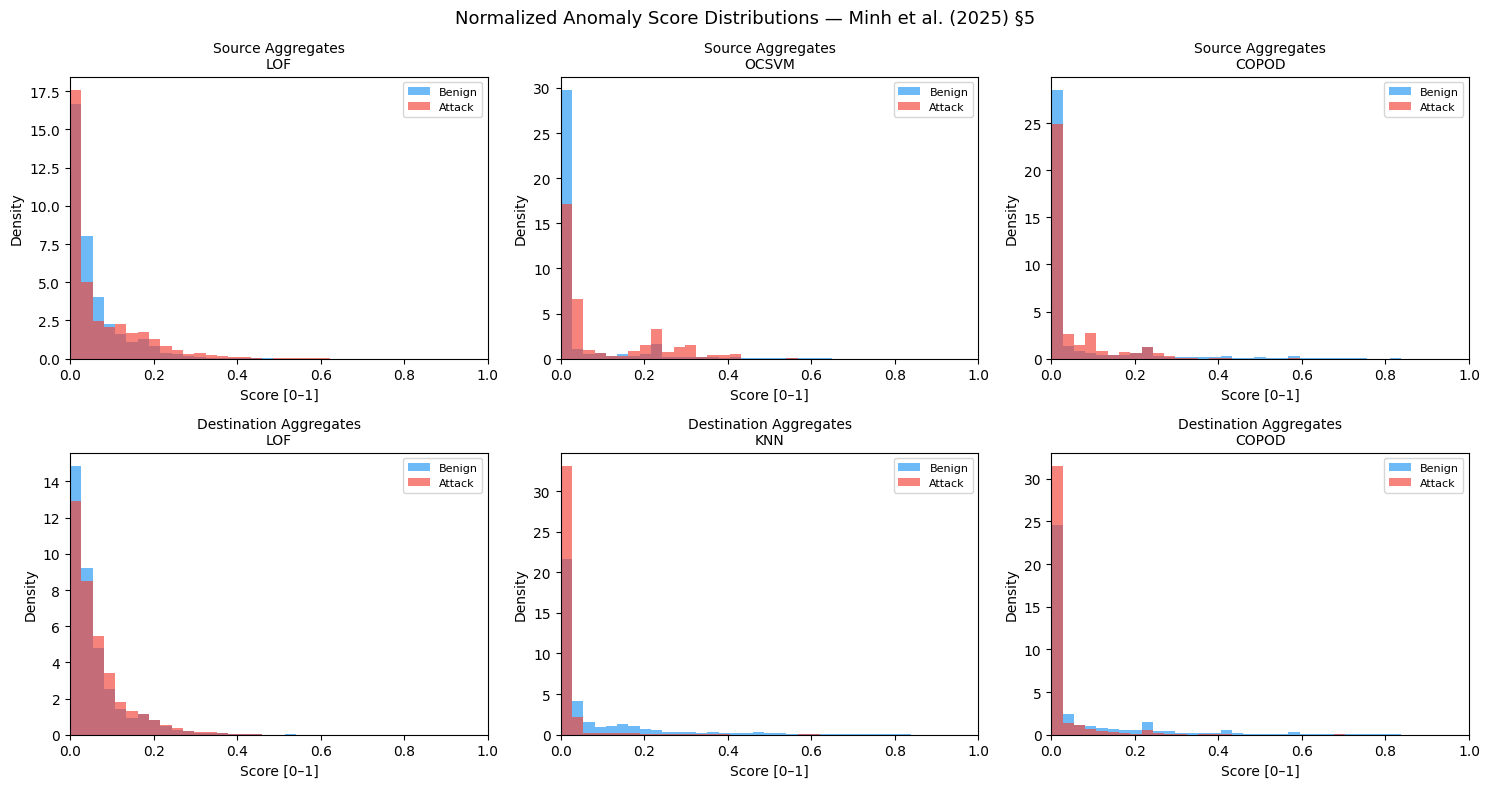


Individual + Ensemble Performance (compare with paper Table 3 & 8):
Perspective       Learner    TPR    FPR
        Src           LOF 0.5251 0.5499
        Src         OCSVM 0.5368 0.1954
        Src         COPOD 0.3260 0.2296
        Dst           LOF 0.6510 0.5984
        Dst           KNN 0.1059 0.4145
        Dst         COPOD 0.1489 0.3364
        Src Ensemble (OR) 0.8719 0.6224
        Dst Ensemble (OR) 0.7092 0.7730


In [35]:
src_scored.to_parquet('/kaggle/working/src_scored.parquet', index=False)
dst_scored.to_parquet('/kaggle/working/dst_scored.parquet', index=False)
print("Saved: src_scored.parquet  dst_scored.parquet")
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']
# ── Score distribution plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Normalized Anomaly Score Distributions — Minh et al. (2025) §5', fontsize=13)
COLORS = {0: '#2196F3', 1: '#F44336'}
NAMES  = {0: 'Benign',  1: 'Attack'}
for row_idx, (scored_df, title, learners) in enumerate([
    (src_scored, 'Source Aggregates',      SRC_LEARNERS),
    (dst_scored, 'Destination Aggregates', DST_LEARNERS),
]):
    for col_idx, learner in enumerate(learners):
        ax  = axes[row_idx][col_idx]
        col = f'score_{learner}'
        for lbl in [0, 1]:
            data = scored_df.loc[scored_df['label'] == lbl, col]
            ax.hist(data, bins=37, alpha=0.65, color=COLORS[lbl],
                    label=NAMES[lbl], density=True, range=(0, 1))
        ax.set_title(f'{title}\n{learner}', fontsize=10)
        ax.set_xlabel('Score [0–1]')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('/kaggle/working/module2_score_distributions.png', dpi=120)
plt.show()
# ── Performance summary table ────────────────────────────────────────────────
rows = []
for learner in SRC_LEARNERS:
    col = f'score_{learner}'
    tpr = (src_scored.loc[src_scored['label']==1, col] > 0).mean()
    fpr = (src_scored.loc[src_scored['label']==0, col] > 0).mean()
    rows.append({'Perspective': 'Src', 'Learner': learner,
                 'TPR': round(tpr, 4), 'FPR': round(fpr, 4)})
for learner in DST_LEARNERS:
    col = f'score_{learner}'
    tpr = (dst_scored.loc[dst_scored['label']==1, col] > 0).mean()
    fpr = (dst_scored.loc[dst_scored['label']==0, col] > 0).mean()
    rows.append({'Perspective': 'Dst', 'Learner': learner,
                 'TPR': round(tpr, 4), 'FPR': round(fpr, 4)})
# Ensemble rows — recomputed here, no dependency on Cell 3/4 variables
tp_src = (src_scored.loc[src_scored['label']==1, 'ensemble_flag']==1).mean()
fp_src = (src_scored.loc[src_scored['label']==0, 'ensemble_flag']==1).mean()
tp_dst = (dst_scored.loc[dst_scored['label']==1, 'ensemble_flag']==1).mean()
fp_dst = (dst_scored.loc[dst_scored['label']==0, 'ensemble_flag']==1).mean()
rows.append({'Perspective':'Src','Learner':'Ensemble (OR)','TPR':round(tp_src,4),'FPR':round(fp_src,4)})
rows.append({'Perspective':'Dst','Learner':'Ensemble (OR)','TPR':round(tp_dst,4),'FPR':round(fp_dst,4)})
perf_df = pd.DataFrame(rows)
print("\nIndividual + Ensemble Performance (compare with paper Table 3 & 8):")
print(perf_df.to_string(index=False))


In [36]:
src_scored = pd.read_parquet('/kaggle/working/src_scored.parquet')
dst_scored = pd.read_parquet('/kaggle/working/dst_scored.parquet')
with open('/kaggle/working/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']
print(f"src_scored : {src_scored.shape}")
print(f"dst_scored : {dst_scored.shape}")
print(src_scored.columns.tolist())

src_scored : (38081, 17)
dst_scored : (28509, 17)
['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_fwd_rate_var', 'f7_bwd_rate_var', 'f8_proto_div', 'f9_dur_var', 'chunk_id', 'label', 'attack_types', 'source_file', 'score_LOF', 'score_OCSVM', 'score_COPOD', 'ensemble_flag']


In [37]:
N_INTERVALS   = 15          # columns per image  (15 × 2 min = 30 min)
MAX_IP_ROWS   = 451         # fixed canvas height (paper value)
# How many consecutive scored rows make one 2-min interval column
# Our aggregates are 100-flow chunks; group ROWS_PER_INTERVAL per column
ROWS_PER_INTERVAL = 1       # 1 chunk = 1 "aggregate" = 1 row in the image
                            # Adjust if your chunk granularity differs
def build_image(scored_df, learner_names, interval_size, n_intervals, max_rows, ip_order):
    """
    Build one RGB heatmap image from a 30-min window.
    Parameters
    ----------
    scored_df     : DataFrame slice for this window (n_rows,)
    learner_names : list of 3 learner names [R, G, B]
    interval_size : rows per 2-min interval
    n_intervals   : number of columns (15)
    max_rows      : canvas height (451)
    ip_order      : pre-shuffled list of row indices (length = max_rows)
    Returns
    -------
    img : (max_rows, n_intervals, 3) uint8 ndarray
    """
    img = np.zeros((max_rows, n_intervals, 3), dtype=np.float32)
    for col_idx in range(n_intervals):
        start = col_idx * interval_size
        end   = start + interval_size
        chunk = scored_df.iloc[start:end] if start < len(scored_df) else pd.DataFrame()
        if chunk.empty:
            continue  # column stays black
        for ch_idx, learner in enumerate(learner_names):
            col_name = f'score_{learner}'
            if col_name not in chunk.columns:
                continue
            score_val = chunk[col_name].mean()
            for row_offset, (_, agg_row) in enumerate(chunk.iterrows()):
                canvas_row = ip_order[row_offset % max_rows]
                img[canvas_row, col_idx, ch_idx] = agg_row[col_name]
    # Scale to uint8
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img
print("Image builder defined.")
print(f"  Image shape per frame : ({MAX_IP_ROWS}, {N_INTERVALS}, 3)")

Image builder defined.
  Image shape per frame : (451, 15, 3)


In [38]:
WINDOW_ROWS = N_INTERVALS * ROWS_PER_INTERVAL   # rows per 30-min window
# Align both DataFrames to the shorter one so we get matching pairs
n_windows = min(len(src_scored), len(dst_scored)) // WINDOW_ROWS
print(f"Rows per window : {WINDOW_ROWS}")
print(f"Total windows   : {n_windows}")
X_src   = []
X_dst   = []
y_labels = []
np.random.seed(42)   # reproducibility
for w in range(n_windows):
    start = w * WINDOW_ROWS
    end   = start + WINDOW_ROWS
    src_win = src_scored.iloc[start:end].reset_index(drop=True)
    dst_win = dst_scored.iloc[start:end].reset_index(drop=True)
    # Randomize IP row order ONCE per window, shared by src and dst
    ip_order = list(np.random.permutation(MAX_IP_ROWS))
    src_img = build_image(src_win, SRC_LEARNERS,
                          ROWS_PER_INTERVAL, N_INTERVALS, MAX_IP_ROWS, ip_order)
    dst_img = build_image(dst_win, DST_LEARNERS,
                          ROWS_PER_INTERVAL, N_INTERVALS, MAX_IP_ROWS, ip_order)
    # Label: attack if any aggregate in window is labelled attack
    label = int(src_win['label'].any() or dst_win['label'].any())
    X_src.append(src_img)
    X_dst.append(dst_img)
    y_labels.append(label)
X_src    = np.stack(X_src,    axis=0)   # (n_windows, 451, 15, 3)
X_dst    = np.stack(X_dst,    axis=0)
y_labels = np.array(y_labels)           # (n_windows,)
print(f"\nX_src shape  : {X_src.shape}")
print(f"X_dst shape  : {X_dst.shape}")
print(f"y shape      : {y_labels.shape}")
print(f"Attack rate  : {y_labels.mean()*100:.2f}%")

Rows per window : 15
Total windows   : 1900

X_src shape  : (1900, 451, 15, 3)
X_dst shape  : (1900, 451, 15, 3)
y shape      : (1900,)
Attack rate  : 52.53%


Saved: X_src.npy  X_dst.npy  y_labels.npy


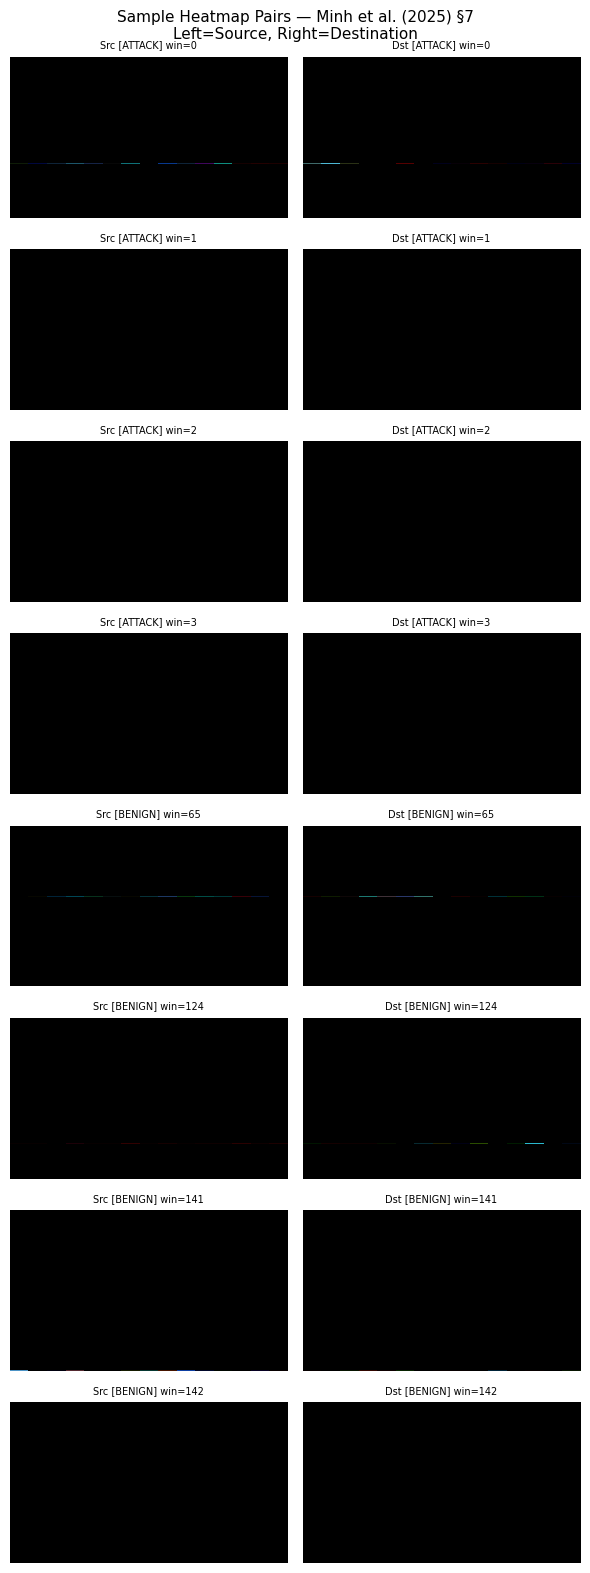

Sample visualization saved.
  Input : image pairs  X_src (1900, 451, 15, 3)  X_dst (1900, 451, 15, 3)
  Labels: y_labels (1900,)  attack_rate=52.53%


In [40]:
np.save('/kaggle/working/X_src.npy',    X_src)
np.save('/kaggle/working/X_dst.npy',    X_dst)
np.save('/kaggle/working/y_labels.npy', y_labels)
print("Saved: X_src.npy  X_dst.npy  y_labels.npy")
# ── Sample visualization ─────────────────────────────────────────────────────
# Show first 4 attack windows and first 4 benign windows
attack_idx = np.where(y_labels == 1)[0][:4]
benign_idx = np.where(y_labels == 0)[0][:4]
sample_idx = list(attack_idx) + list(benign_idx)
fig, axes = plt.subplots(len(sample_idx), 2,
                         figsize=(6, len(sample_idx) * 2))
fig.suptitle('Sample Heatmap Pairs — Minh et al. (2025) §7\n'
             'Left=Source, Right=Destination', fontsize=11)
for row, idx in enumerate(sample_idx):
    lbl = "ATTACK" if y_labels[idx] else "BENIGN"
    axes[row][0].imshow(X_src[idx], aspect='auto', interpolation='nearest')
    axes[row][0].set_title(f"Src [{lbl}] win={idx}", fontsize=7)
    axes[row][0].axis('off')
    axes[row][1].imshow(X_dst[idx], aspect='auto', interpolation='nearest')
    axes[row][1].set_title(f"Dst [{lbl}] win={idx}", fontsize=7)
    axes[row][1].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/module3_sample_heatmaps.png', dpi=100)
plt.show()
print("Sample visualization saved.")
print(f"  Input : image pairs  X_src {X_src.shape}  X_dst {X_dst.shape}")
print(f"  Labels: y_labels {y_labels.shape}  attack_rate={y_labels.mean()*100:.2f}%")

In [41]:

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
# Reload
X_src    = np.load('/kaggle/working/X_src.npy')
X_dst    = np.load('/kaggle/working/X_dst.npy')
y_labels = np.load('/kaggle/working/y_labels.npy')
# Normalize pixel values to [0,1]  (paper §12.5)
X_src = X_src.astype(np.float32) / 255.0
X_dst = X_dst.astype(np.float32) / 255.0
print(f"X_src  : {X_src.shape}  dtype={X_src.dtype}")
print(f"X_dst  : {X_dst.shape}  dtype={X_dst.dtype}")
print(f"y      : {y_labels.shape}  attack_rate={y_labels.mean()*100:.2f}%")
# Reproducible shuffle
np.random.seed(42)
idx = np.random.permutation(len(y_labels))
X_src    = X_src[idx]
X_dst    = X_dst[idx]
y_labels = y_labels[idx]
n       = len(y_labels)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
X_src_train, X_src_val, X_src_test = X_src[:n_train], X_src[n_train:n_train+n_val], X_src[n_train+n_val:]
X_dst_train, X_dst_val, X_dst_test = X_dst[:n_train], X_dst[n_train:n_train+n_val], X_dst[n_train+n_val:]
y_train, y_val, y_test             = y_labels[:n_train], y_labels[n_train:n_train+n_val], y_labels[n_train+n_val:]
print(f"\nTrain : {len(y_train)}  attack={y_train.mean()*100:.1f}%")
print(f"Val   : {len(y_val)}   attack={y_val.mean()*100:.1f}%")
print(f"Test  : {len(y_test)}   attack={y_test.mean()*100:.1f}%")

2026-04-29 19:57:32.699291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777492653.104990      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777492653.230535      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777492654.200631      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777492654.200668      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777492654.200670      57 computation_placer.cc:177] computation placer alr

X_src  : (1900, 451, 15, 3)  dtype=float32
X_dst  : (1900, 451, 15, 3)  dtype=float32
y      : (1900,)  attack_rate=52.53%

Train : 1520  attack=53.5%
Val   : 190   attack=43.7%
Test  : 190   attack=53.7%


In [42]:
from tensorflow.keras import layers, models
IMG_H, IMG_W, IMG_C = 451, 15, 3
def conv_branch(inp, branch_name):
    x = layers.Conv2D(32, (3, 3), activation='relu',
                      padding='same', name=f'{branch_name}_c1')(inp)
    x = layers.MaxPooling2D((2, 2), name=f'{branch_name}_p1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu',
                      padding='same', name=f'{branch_name}_c2')(x)
    x = layers.MaxPooling2D((2, 2), name=f'{branch_name}_p2')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu',
                      padding='same', name=f'{branch_name}_c3')(x)
    x = layers.GlobalAveragePooling2D(name=f'{branch_name}_gap')(x)
    return x
src_input = tf.keras.Input(shape=(IMG_H, IMG_W, IMG_C), name='src_input')
dst_input = tf.keras.Input(shape=(IMG_H, IMG_W, IMG_C), name='dst_input')
src_feat = conv_branch(src_input, 'src')
dst_feat = conv_branch(dst_input, 'dst')
merged = layers.Concatenate(name='concat')([src_feat, dst_feat])
x      = layers.Dense(256, activation='relu', name='dense1')(merged)
x      = layers.Dropout(0.4, name='drop1')(x)
output = layers.Dense(1, activation='sigmoid', name='output')(x)
model = tf.keras.Model(inputs=[src_input, dst_input], outputs=output,
                       name='NIDS_CNN')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
model.summary()

I0000 00:00:1777492711.768237      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777492711.774054      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "NIDS_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ src_input           │ (None, 451, 15,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_input           │ (None, 451, 15,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_c1 (Conv2D)     │ (None, 451, 15,   │        896 │ src_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_c1 (Conv2D)     │ (None, 451, 15,   │        896 │ dst_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_p1              │ (None, 225, 7,    │          0 │ src_c1[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_p1              │ (None, 225, 7,    │          0 │ dst_c1[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_c2 (Conv2D)     │ (None, 225, 7,    │     18,496 │ src_p1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_c2 (Conv2D)     │ (None, 225, 7,    │     18,496 │ dst_p1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_p2              │ (None, 112, 3,    │          0 │ src_c2[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_p2              │ (None, 112, 3,    │          0 │ dst_c2[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_c3 (Conv2D)     │ (None, 112, 3,    │     73,856 │ src_p2[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_c3 (Conv2D)     │ (None, 112, 3,    │     73,856 │ dst_p2[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_gap             │ (None, 128)       │          0 │ src_c3[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_gap             │ (None, 128)       │          0 │ dst_c3[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 256)       │          0 │ src_gap[0][0],    │
│ (Concatenate)       │                   │            │ dst_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │     65,792 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 256)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 252,545 (986.50 KB)

 Trainable params: 252,545 (986.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
cw = compute_class_weight('balanced',
                          classes=np.array([0, 1]),
                          y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f"Class weights: benign={cw[0]:.3f}  attack={cw[1]:.3f}")
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=8,
        restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=4, min_lr=1e-6, mode='max'),
    tf.keras.callbacks.ModelCheckpoint(
        '/kaggle/working/best_cnn.keras',
        monitor='val_auc', save_best_only=True, mode='max')
]
history = model.fit(
    [X_src_train, X_dst_train], y_train,
    validation_data=([X_src_val, X_dst_val], y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining complete.")

Class weights: benign=1.075  attack=0.935
Epoch 1/50


I0000 00:00:1777492717.072436     392 service.cc:152] XLA service 0x7a0224056b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777492717.072470     392 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777492717.072473     392 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777492717.786309     392 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-29 19:58:40.199816: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 19:58:40.368968: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 19:58:41.204630: E external/local_xl

 5/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4573 - auc: 0.4889 - loss: 0.6934 - precision: 0.4964 - recall: 0.5706

I0000 00:00:1777492724.304897     392 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5352 - auc: 0.5198 - loss: 0.6912 - precision: 0.5478 - recall: 0.8337

2026-04-29 19:58:46.356729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 19:58:46.520247: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 164ms/step - accuracy: 0.5363 - auc: 0.5222 - loss: 0.6911 - precision: 0.5488 - recall: 0.8255 - val_accuracy: 0.7158 - val_auc: 0.7902 - val_loss: 0.6617 - val_precision: 0.7736 - val_recall: 0.4940 - learning_rate: 0.0010
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7357 - auc: 0.7919 - loss: 0.6195 - precision: 0.7715 - recall: 0.7202 - val_accuracy: 0.7684 - val_auc: 0.8567 - val_loss: 0.5135 - val_precision: 0.6931 - val_recall: 0.8434 - learning_rate: 0.0010
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8064 - auc: 0.8690 - loss: 0.4896 - precision: 0.8111 - recall: 0.8388 - val_accuracy: 0.8158 - val_auc: 0.8797 - val_loss: 0.4503 - val_precision: 0.7609 - val_recall: 0.8434 - learning_rate: 0.0010
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8283 - auc: 0.8848 - loss: 0.4400 - precision: 0.8397 - recall: 0.8295 - val_accuracy: 0.8526 - val_auc: 0.8835 - val_loss: 0.3944 - val_precision: 0

CNN Test Set Results  (compare with paper Table 9)
  TP=86  FP=8  FN=16  TN=80
  TPR (Recall) : 0.8431   [paper Combined: 0.9898]
  FPR          : 0.0909   [paper Combined: 0.0093]
  Precision    : 0.9149
  F1-score     : 0.8776   [paper Combined: 0.9906]
  AUC-ROC      : 0.9367

              precision    recall  f1-score   support

      Benign       0.83      0.91      0.87        88
      Attack       0.91      0.84      0.88       102

    accuracy                           0.87       190
   macro avg       0.87      0.88      0.87       190
weighted avg       0.88      0.87      0.87       190



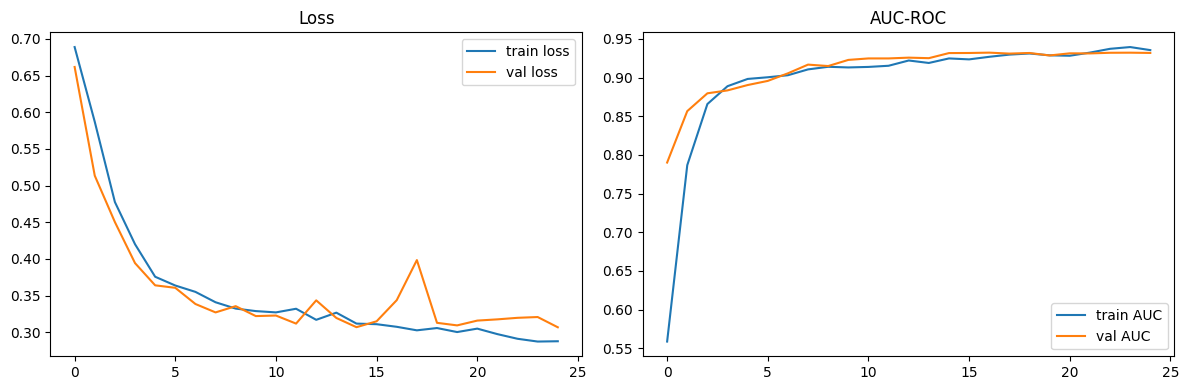

In [44]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score)
# Load best checkpoint
model = tf.keras.models.load_model('/kaggle/working/best_cnn.keras')
# Predict on test set
y_prob = model.predict([X_src_test, X_dst_test], verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
# Metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1   = 2 * prec * tpr / (prec + tpr) if (prec + tpr) > 0 else 0.0
auc  = roc_auc_score(y_test, y_prob)
print("=" * 55)
print("CNN Test Set Results  (compare with paper Table 9)")
print("=" * 55)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  TPR (Recall) : {tpr:.4f}   [paper Combined: 0.9898]")
print(f"  FPR          : {fpr:.4f}   [paper Combined: 0.0093]")
print(f"  Precision    : {prec:.4f}")
print(f"  F1-score     : {f1:.4f}   [paper Combined: 0.9906]")
print(f"  AUC-ROC      : {auc:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Attack']))
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['auc'],     label='train AUC')
axes[1].plot(history.history['val_auc'], label='val AUC')
axes[1].set_title('AUC-ROC')
axes[1].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/module4_training_curves.png', dpi=100)
plt.show()
np.save('/kaggle/working/y_test.npy',  y_test)
np.save('/kaggle/working/y_prob.npy',  y_prob)
np.save('/kaggle/working/y_pred.npy',  y_pred)